Title: B&C_Reduction.py

Author: Quin Aicken Davies

Date: 04/11/2025

Description: Perform reduction of B&C data using parts of theASTR211 reduction pipeline 
edited to work in this file. Major adjustments include handling different exposure times for darks,
bias correction for flats, saving reduced science images to a specified directory, and more 
efficient file opening. 

This file is a streamlined version of the B&C_Reduction.py


In [26]:
import os # A module for communicating with the operating system e.g. commands and files
import glob # A module for searching data files
# from os import killpg

import matplotlib.pyplot as plt # A plotting library
import numpy as np # Numerical Python, great for vectorised equations
import scipy # Scientific Python, great for algorithms and optimisation
import pandas as pd # DataFrames for organising data/tables
from astropy.io import fits # Astronomy Python for opening ".fits" files
from photutils.background import Background2D, MedianBackground # Fitting background surfaces to astronomical images
from copy import deepcopy # A module for copying objects
import warnings # To ignore our problems

warnings.filterwarnings('ignore', category=RuntimeWarning) #Ignores some warnings

In [27]:
#%% Census Code
#Name of target
star = 'ZZ_Psc'
# folders = ['20251119','20251122','20251123']
folder = '20251123' # Change this to the folder you want to process
#Define Folders
if os.path.exists('/home/users/qai11/'):
    main_folder = f'/home/users/qai11/data/Photometery_RAW/{folder}/' # Filenames are descriptive, exact files, minimum exposures times
    flats_folder = '/home/users/qai11/data/Photometery_RAW/20250913/'
    output_folder = '/home/users/qai11/Documents/Reduced_files/'
    print('Running on university cluster')
else:
    print('Running on local machine')
    main_folder = f'E:/Summer 2025 Data/zzpscdata/{folder}/' 
    # flats_folder = 'E:/Summer 2025 Data/Summer_Project/Photometery_RAW/20250913/'
    if os.path.exists('E:/Summer 2025 Data/zzpscdata/Reduced'):
        output_folder = 'E:/Summer 2025 Data/zzpscdata/Reduced/'
    else:
        #Create the flats folder if it does not exist
        os.mkdir('E:/Summer 2025 Data/zzpscdata/Reduced_files/')
        output_folder = 'E:/Summer 2025 Data/zzpscdata/Reduced_files/'

'''Read in the flats, darks, bias and science files'''
#Science Files
science_files = glob.glob(main_folder + f'{star}-*_g.fit*')
#Open science file to check exposure times
file = science_files[0]  # Select the first file
hdul = fits.open(file)
hdr = hdul[0].header
dark_exp = hdr["EXPTIME"]
hdul.close()
science_darks = glob.glob(main_folder + f'dark-*d{int(dark_exp)}.fit*')

# Flats reduced with g filter
flat_files = glob.glob('E:/Summer 2025 Data/Reduced_files/master_flat_combined.fits')
use_reduced_flat = True
# flat_files = None
if flat_files == None:
    use_reduced_flat = False
    #Flat files
    flat_files = glob.glob(main_folder + '*Flat**g*.fit*')
    # print(len(flat_files))
    # Darks for flats
    file = flat_files[0]  # Select the first file
    hdul = fits.open(file)
    hdr = hdul[0].header
    dark_exp = hdr["EXPTIME"]
    hdul.close()
    flat_darks = glob.glob(flats_folder + f'*dark*d{int(dark_exp)}.fit*')
else:
    flat_darks = []
#bias files
bias_files = glob.glob(main_folder + '*bias*.fit*')


# Check how many files of each type we have
print(f'Number of science files: {len(science_files)}')
print(f'Number of science dark files: {len(science_darks)}')
print(f'Number of flat files: {len(flat_files)}')
print(f'Number of darks for flats files: {len(flat_darks)}')
print(f'Number of bias files: {len(bias_files)}')


Running on local machine
Number of science files: 11
Number of science dark files: 6
Number of flat files: 1
Number of darks for flats files: 0
Number of bias files: 6


In [28]:
"""Print out the stats for each file type"""
print("Science Files")
for file in science_files:
    hdul = fits.open(file)
    hdr = hdul[0].header
    print(f'EXPTIME: {hdr["EXPTIME"]}, FILTER: {hdr["FILTER"]}, Readout: {hdr["READOUTM"]}, CCDTEMP: {hdr["CCD-TEMP"]}')
    hdul.close()
print("Science Darks")
for file in science_darks:
    hdul = fits.open(file)
    hdr = hdul[0].header
    print(f'EXPTIME: {hdr["EXPTIME"]}, Readout: {hdr["READOUTM"]}, CCDTEMP: {hdr["CCD-TEMP"]}')
    hdul.close()
print("Flats")
if use_reduced_flat == False:
    for file in flat_files:
        hdul = fits.open(file)
        hdr = hdul[0].header
        print(f'EXPTIME: {hdr["EXPTIME"]}, FILTER: {hdr["FILTER"]}, Readout: {hdr["READOUTM"]}, CCDTEMP: {hdr["CCD-TEMP"]}')
        hdul.close()
else:
    None
print("flat Darks")
for file in flat_darks:
    hdul = fits.open(file)
    hdr = hdul[0].header
    print(f'EXPTIME: {hdr["EXPTIME"]}, Readout: {hdr["READOUTM"]}, CCDTEMP: {hdr["CCD-TEMP"]}')
    hdul.close()



Science Files
EXPTIME: 40.0, FILTER: g, Readout: 500KHz, CCDTEMP: -40.0
EXPTIME: 40.0, FILTER: g, Readout: 500KHz, CCDTEMP: -40.0
EXPTIME: 40.0, FILTER: g, Readout: 500KHz, CCDTEMP: -40.0
EXPTIME: 40.0, FILTER: g, Readout: 500KHz, CCDTEMP: -40.0
EXPTIME: 40.0, FILTER: g, Readout: 500KHz, CCDTEMP: -40.0
EXPTIME: 40.0, FILTER: g, Readout: 500KHz, CCDTEMP: -40.0
EXPTIME: 40.0, FILTER: g, Readout: 500KHz, CCDTEMP: -40.0
EXPTIME: 40.0, FILTER: g, Readout: 500KHz, CCDTEMP: -40.0
EXPTIME: 40.0, FILTER: g, Readout: 500KHz, CCDTEMP: -40.0
EXPTIME: 40.0, FILTER: g, Readout: 500KHz, CCDTEMP: -40.0
EXPTIME: 40.0, FILTER: g, Readout: 500KHz, CCDTEMP: -40.0
Science Darks
EXPTIME: 40.0, Readout: 500KHz, CCDTEMP: -40.0
EXPTIME: 40.0, Readout: 500KHz, CCDTEMP: -40.0
EXPTIME: 40.0, Readout: 500KHz, CCDTEMP: -40.0
EXPTIME: 40.0, Readout: 500KHz, CCDTEMP: -40.0
EXPTIME: 40.0, Readout: 500KHz, CCDTEMP: -40.0
EXPTIME: 40.0, Readout: 500KHz, CCDTEMP: -40.0
Flats
flat Darks


In [29]:
"""Open the files and sort them into data arrays"""
# sorting the infromation based on header information
science_darks_data = []
flat_darks_data = []
flats_data = []
science_data = []
science_hdr = []
bias_data = []
flats_headers = []

# Combine file processing into a single loop for each category
for file in science_darks + flat_darks + flat_files + science_files + bias_files:
    hdul = fits.open(file)
    hdr = hdul[0].header
    data = hdul[0].data.copy()
    
    if file in science_darks:
        science_darks_data.append(data)
    elif file in science_files:
        science_data.append(data)
        science_hdr.append(hdr)  # Store the header of the last science file for later use
    elif file in bias_files:
        bias_data.append(data)
    elif use_reduced_flat == False:
        if file in flat_darks:
            flat_darks_data.append(data)
        elif file in flat_files:
            if np.nanmedian(data) > 20000:
                flats_data.append(data)
                flats_headers.append(hdr)
    else:
        pass
    hdul.close()

In [30]:
"""Create Master Darks"""
master_dark_science = np.median(np.array(science_darks_data), axis=0)
master_dark_flat = np.median(np.array(flat_darks_data), axis=0)
#Save master dark science
if not os.path.exists(output_folder+f'/{folder}'):
    os.makedirs(output_folder+f'/{folder}')
hdu = fits.PrimaryHDU(master_dark_science)
hdu.writeto(output_folder+f'/{folder}/master_dark_science.fits', overwrite=True)
if use_reduced_flat == False:
    #Save master dark flat
    hdu = fits.PrimaryHDU(master_dark_flat)
    hdu.writeto(output_folder+f'/{folder}/master_dark_flat.fits', overwrite=True)
else:
    pass


In [31]:
"""Create Master Flat"""
if use_reduced_flat == False:
    corrected_flats = []
    average_bias = np.nanmedian(bias_data)  # Calculate average bias

    for flat, hdr in zip(flats_data, flats_headers):
        
        try:
            corrected = flat - master_dark_flat - average_bias
            corrected_flats.append(corrected / np.nanmedian(corrected))
        except Exception as e:
            print(f"Skipping flat due to error: {e}")
            continue
    master_flat = np.median(np.array(corrected_flats), axis=0)
    #Save the master flat
    hdu = fits.PrimaryHDU(master_flat)
    hdu.writeto(output_folder +f'/{folder}/master_flat.fits', overwrite=True)
else:
    #Open the reduced flat file
    flat_hdul = fits.open(flat_files[0])
    master_flat = flat_hdul[0].data

In [32]:
"""Reduce Science Images"""
reduced_science_images = []
for science in science_data:
    corrected_science = (science - master_dark_science) / master_flat
    reduced_science_images.append(corrected_science)

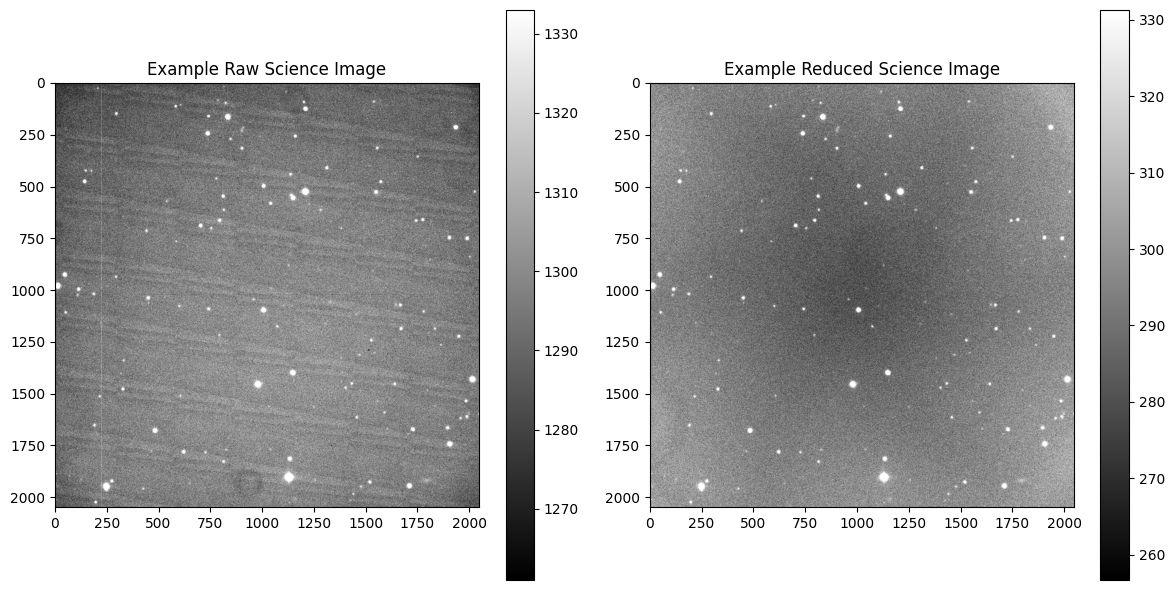

In [33]:
"""Plot a reduced science image to check"""

plt.figure(figsize=(12, 6))

# Plot the raw science image
plt.subplot(1, 2, 1)
plt.imshow(science_data[0], cmap='gray', vmin=np.nanpercentile(science_data[0], 2), vmax=np.nanpercentile(science_data[0], 98))
plt.title('Example Raw Science Image')
plt.colorbar()

# Plot the reduced science image
plt.subplot(1, 2, 2)
plt.imshow(reduced_science_images[0], cmap='gray', vmin=np.nanpercentile(reduced_science_images[0], 2), vmax=np.nanpercentile(reduced_science_images[0], 98))
plt.title('Example Reduced Science Image')
plt.colorbar()

plt.tight_layout()
plt.show()

In [34]:
"""Save Reduced Images"""
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
if not os.path.exists(output_folder+f'/{folder}'):
    os.makedirs(output_folder+f'/{folder}')
for i, (reduced_image, hdr) in enumerate(zip(reduced_science_images, science_hdr)):
    hdu = fits.PrimaryHDU(reduced_image, header=fits.Header(hdr))
    # hdu = fits.HDUList([hdu])
    original_name = os.path.basename(science_files[i])
    output_filename = os.path.join(output_folder, f"{os.path.splitext(original_name)[0]}_reduced_{folder}{os.path.splitext(original_name)[1]}") 
    hdr['TITLE'] = f"Reduced Image: {os.path.basename(output_filename)}"
    hdu.writeto(output_filename, overwrite=True)
    print(f'Saved: {output_filename}')
    

Saved: E:/Summer 2025 Data/zzpscdata/Reduced/ZZ_Psc-0001_g_reduced_20251123.fit
Saved: E:/Summer 2025 Data/zzpscdata/Reduced/ZZ_Psc-0002_g_reduced_20251123.fit
Saved: E:/Summer 2025 Data/zzpscdata/Reduced/ZZ_Psc-0003_g_reduced_20251123.fit
Saved: E:/Summer 2025 Data/zzpscdata/Reduced/ZZ_Psc-0004_g_reduced_20251123.fit
Saved: E:/Summer 2025 Data/zzpscdata/Reduced/ZZ_Psc-0005_g_reduced_20251123.fit
Saved: E:/Summer 2025 Data/zzpscdata/Reduced/ZZ_Psc-0006_g_reduced_20251123.fit
Saved: E:/Summer 2025 Data/zzpscdata/Reduced/ZZ_Psc-0007_g_reduced_20251123.fit
Saved: E:/Summer 2025 Data/zzpscdata/Reduced/ZZ_Psc-0008_g_reduced_20251123.fit
Saved: E:/Summer 2025 Data/zzpscdata/Reduced/ZZ_Psc-0009_g_reduced_20251123.fit
Saved: E:/Summer 2025 Data/zzpscdata/Reduced/ZZ_Psc-0010_g_reduced_20251123.fit
Saved: E:/Summer 2025 Data/zzpscdata/Reduced/ZZ_Psc-0011_g_reduced_20251123.fit
